In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
df=pd.read_csv("C:/Users/revat/Downloads/Telecom_Customer_Churn_Dataset.csv")

In [5]:
df

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,52,1541.42,75408.44,Two Year,No,UPI,No
1,CUST00002,15,1317.97,73419.49,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,61,409.64,87681.15,Month-to-Month,No,Credit Card,No
3,CUST00004,21,1791.31,72417.07,Two Year,DSL,Bank Transfer,No
4,CUST00005,24,1791.34,23568.21,One Year,Fiber Optic,Debit Card,No
...,...,...,...,...,...,...,...,...
2495,CUST02496,33,479.19,25890.63,Month-to-Month,No,Debit Card,No
2496,CUST02497,52,1241.50,85917.79,Two Year,No,Credit Card,No
2497,CUST02498,14,1172.06,54865.85,Month-to-Month,No,Credit Card,Yes
2498,CUST02499,53,778.37,57162.91,One Year,Fiber Optic,UPI,No


In [6]:
df.columns

Index(['CustomerID', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges',
       'Contract_Type', 'Internet_Service', 'Payment_Method', 'Churn'],
      dtype='object')

In [7]:
df.tail()

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
2495,CUST02496,33,479.19,25890.63,Month-to-Month,No,Debit Card,No
2496,CUST02497,52,1241.50,85917.79,Two Year,No,Credit Card,No
2497,CUST02498,14,1172.06,54865.85,Month-to-Month,No,Credit Card,Yes
2498,CUST02499,53,778.37,57162.91,One Year,Fiber Optic,UPI,No
2499,CUST02500,59,1697.79,34645.80,Month-to-Month,Fiber Optic,UPI,No


In [8]:
df.head()

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,52,1541.42,75408.44,Two Year,No,UPI,No
1,CUST00002,15,1317.97,73419.49,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,61,409.64,87681.15,Month-to-Month,No,Credit Card,No
3,CUST00004,21,1791.31,72417.07,Two Year,DSL,Bank Transfer,No
4,CUST00005,24,1791.34,23568.21,One Year,Fiber Optic,Debit Card,No


In [9]:
df.describe()

,Tenure_Months,Monthly_Charges,Total_Charges
count,2500.000000,2500.000000,2500.000000
mean,35.110800,1151.734676,49905.849216
std,20.479509,490.233166,28609.479902
min,1.000000,300.320000,562.440000
25%,17.000000,731.127500,25845.335000
50%,35.000000,1167.605000,50212.670000
75%,53.000000,1581.170000,74179.852500
max,71.000000,1999.510000,99985.000000


In [10]:
df.isnull().sum()

CustomerID          0
Tenure_Months       0
Monthly_Charges     0
Total_Charges       0
Contract_Type       0
Internet_Service    0
Payment_Method      0
Churn               0
dtype: int64

# DATA PREPROCESSING

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
a=df.select_dtypes(include=('object'))

In [13]:
a

,CustomerID,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,Two Year,No,UPI,No
1,CUST00002,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,Month-to-Month,No,Credit Card,No
3,CUST00004,Two Year,DSL,Bank Transfer,No
4,CUST00005,One Year,Fiber Optic,Debit Card,No
...,...,...,...,...,...
2495,CUST02496,Month-to-Month,No,Debit Card,No
2496,CUST02497,Two Year,No,Credit Card,No
2497,CUST02498,Month-to-Month,No,Credit Card,Yes
2498,CUST02499,One Year,Fiber Optic,UPI,No


In [14]:
b= a.drop("CustomerID", axis =1 )

In [15]:
b

,Contract_Type,Internet_Service,Payment_Method,Churn
0,Two Year,No,UPI,No
1,Month-to-Month,DSL,Bank Transfer,No
2,Month-to-Month,No,Credit Card,No
3,Two Year,DSL,Bank Transfer,No
4,One Year,Fiber Optic,Debit Card,No
...,...,...,...,...
2495,Month-to-Month,No,Debit Card,No
2496,Two Year,No,Credit Card,No
2497,Month-to-Month,No,Credit Card,Yes
2498,One Year,Fiber Optic,UPI,No


In [18]:
for i in b:
    b[i]=LabelEncoder().fit_transform(b[i])

# feature scalling

In [23]:
c=df.select_dtypes(include = np.number)

In [26]:
c

,Tenure_Months,Monthly_Charges,Total_Charges
0,52,1541.42,75408.44
1,15,1317.97,73419.49
2,61,409.64,87681.15
3,21,1791.31,72417.07
4,24,1791.34,23568.21
...,...,...,...
2495,33,479.19,25890.63
2496,52,1241.50,85917.79
2497,14,1172.06,54865.85
2498,53,778.37,57162.91


In [24]:
from sklearn.preprocessing import StandardScaler

In [29]:
e=pd.DataFrame(StandardScaler().fit_transform(c),columns=['Tenure_Months','Monthly_Charges','Total_Charges'])

In [40]:
df=pd.concat([b,e],axis=1)

In [48]:
df

,Contract_Type,Internet_Service,Payment_Method,Churn,Tenure_Months,Monthly_Charges,Total_Charges
0,2,2,3,0,0.824853,0.795057,0.891582
1,0,0,0,0,-0.982193,0.339162,0.822047
2,0,2,1,0,1.264404,-1.514061,1.320641
3,2,0,0,0,-0.689158,1.304896,0.787002
4,1,1,2,0,-0.542641,1.304957,-0.920776
...,...,...,...,...,...,...,...
2495,0,2,2,0,-0.103089,-1.372162,-0.839583
2496,2,2,1,0,0.824853,0.183144,1.258993
2497,0,2,1,1,-1.031032,0.041469,0.173404
2498,1,1,3,0,0.873692,-0.761759,0.253710


# Feature Extraction

In [49]:
y=df['Churn']  ##Target
x=df.drop("Churn",axis=1)    ##Feature

# train_test_split

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

# Model Deployment

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
model = LogisticRegression()

In [54]:
model

LogisticRegression()

In [55]:
model.fit(x_train,y_train)

LogisticRegression()

# predicting the churn

In [59]:
data={'Contract_Type':[1],
      'Internet_Service':[1],
      'Payment_Method':[3],
      'Tenure_Months':[0.8],
      'Monthly_Charges':[0.7],w
      'Total_Charges':[0.8]}
new_customer=pd.DataFrame(data)

In [60]:
new_customer

,Contract_Type,Internet_Service,Payment_Method,Tenure_Months,Monthly_Charges,Total_Charges
0,1,1,3,0.8,0.7,0.8


In [61]:
print("model Prediction:",model.predict(new_customer))

model Prediction: [0]


In [64]:
y_pred=model.predict(x_test)

# Model Evalution

In [65]:
from sklearn.metrics import accuracy_score,classification_report

In [66]:
accuracy_score(y_test,y_pred)

0.7355

In [67]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1471
           1       0.00      0.00      0.00       529

    accuracy                           0.74      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.74      0.62      2000



C:\Users\revat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\revat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\revat\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
## to check why the customer has churn we use feature importance

In [69]:
model.coef_[0]

array([-0.07036995,  0.19137196, -0.15217695,  0.14754878,  0.09093535,
       -0.11128102])

In [70]:
x.columns

Index(['Contract_Type', 'Internet_Service', 'Payment_Method', 'Tenure_Months',
       'Monthly_Charges', 'Total_Charges'],
      dtype='object')

In [71]:
import matplotlib.pyplot as plt

<BarContainer object of 6 artists>

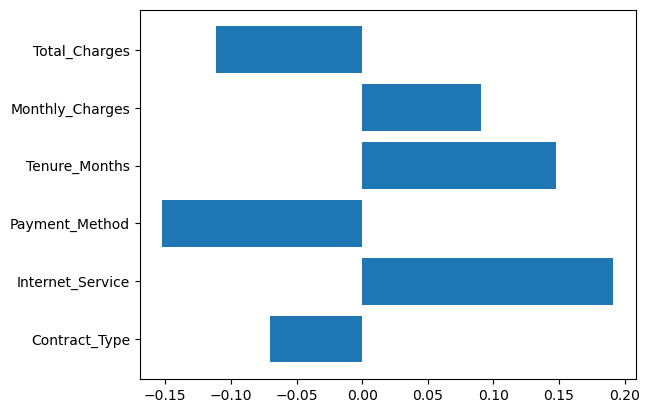

In [72]:
plt.barh(x.columns,model.coef_[0])